In [40]:
import jax.numpy as jnp
import immrax as irx
from immutabledict import immutabledict
from faulty_nonholonomic_car import FaultyNonHolonomicCar
# Define initial state bounds (intervals) using icentpert



# Create system instance with steering parameter p
car_system = FaultyNonHolonomicCar(p=0.8)

# Define the time horizon for reachability analysis
time_horizon = 1.0  # seconds
num_steps = 10  # Number of time steps

def propagate_interval(system, x0_interval, u_fixed, w_fixed, t_end, dt=0.01):
    """
    Propagate the interval of states through the system dynamics for a fixed input.
    
    Args:
        system: The system with dynamics defined.
        x0_interval: Initial interval of states (as an interval object).
        u_fixed: Fixed control input (as a jnp.array).
        w_fixed: Fixed disturbance input (as a jnp.array).
        t_end: End time for propagation (e.g., 1 second).
        dt: Time step for numerical integration.
    
    Returns:
        Interval of states after propagation.
    """
    # Initialize the state interval
    x_interval = x0_interval

    # Time steps
    num_steps = int(t_end / dt)

    # Propagate the interval through the dynamics
    for _ in range(num_steps):
        # Compute the dynamics for the lower and upper bounds of the interval
        x_lower = x_interval.lower
        x_upper = x_interval.upper

        dx_lower = system.f(0, x_lower, u_fixed, w_fixed)
        dx_upper = system.f(0, x_upper, u_fixed, w_fixed)

        # Update the interval bounds using interval arithmetic
        x_lower_new = x_lower + dx_lower * dt
        x_upper_new = x_upper + dx_upper * dt

        # Create a new interval for the updated state
        x_interval = irx.interval(x_lower_new, x_upper_new)

    return x_interval

car_system = FaultyNonHolonomicCar(p=0.)

# Define the initial interval of states
x0 = jnp.zeros(4)
x0_perturbation = jnp.array([.1, .1, .1, .1])
x0_interval = irx.icentpert(x0, x0_perturbation)

# Define the fixed control input and disturbance
u_fixed = jnp.array([0.2, 0.2])  # Fixed control input
w_fixed = jnp.array([jnp.pi/4])  # Fixed disturbance. Assume steering angle is fixed at 45 deg.

# Propagate the interval for 1 second
t_end = 1.0  # 1 second
x_interval_actuator_fault = propagate_interval(car_system, x0_interval, u_fixed, w_fixed, t_end)

# Print the resulting interval of states
print("Initial interval of states:", x0_interval)
print("Final interval of states after 1 second:", x_interval_actuator_fault)

Initial interval of states: [[(-0.1, 0.1)]
 [(-0.1, 0.1)]
 [(-0.1, 0.1)]
 [(-0.1, 0.1)]]
Final interval of states after 1 second: [[(0.24415359, 0.57590002)]
 [(0.0684815 , 0.42500934)]
 [(0.6853984 , 0.88539845)]
 [(0.88539755, 1.08539712)]]


Generate Interval WITHOUT Actuator Fault

In [41]:
normal_car_system = FaultyNonHolonomicCar(p=1.)

# Define the initial interval of states
x0 = jnp.zeros(4)
x0_perturbation = jnp.array([.1, .1, .1, .1])
x0_interval = irx.icentpert(x0, x0_perturbation)

# Define the fixed control input and disturbance
u_fixed = jnp.array([0.2, 0.2])  # Fixed control input
w_fixed = jnp.array([jnp.pi/4])  # Fixed disturbance. Assume steering angle is fixed at 45 deg.

# Propagate the interval for 1 second
t_end = 1.0  # 1 second
x_interval_no_fault = propagate_interval(normal_car_system, x0_interval, u_fixed, w_fixed, t_end)

# Print the resulting interval of states
print("Initial interval of states:", x0_interval)
print("Final interval of states after 1 second:", x_interval_no_fault)

Initial interval of states: [[(-0.1, 0.1)]
 [(-0.1, 0.1)]
 [(-0.1, 0.1)]
 [(-0.1, 0.1)]]
Final interval of states after 1 second: [[(0.21477631, 0.52579677)]
 [(0.11386681, 0.47860932)]
 [(0.88539755, 1.08539712)]
 [(0.88539755, 1.08539712)]]


Add an observation fault

In [48]:
offset = jnp.array([0.2, 0.2, 0., 0.2])
x_interval_observation_fault = x_interval_no_fault + offset

Plot observation of system

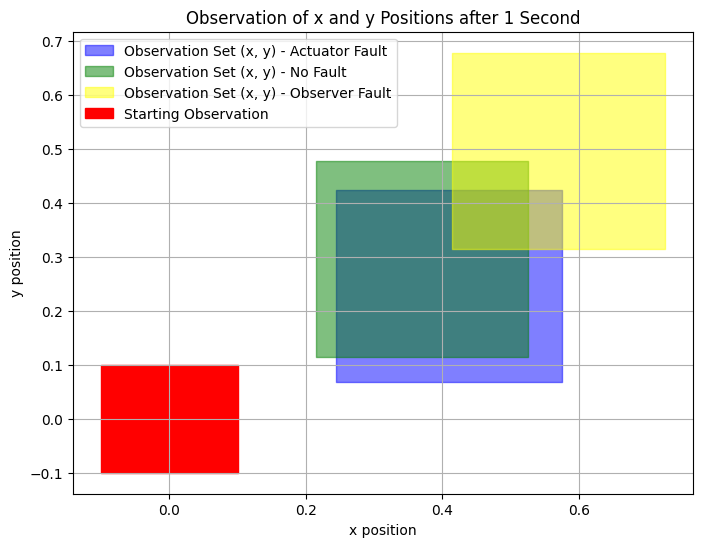

In [51]:
import matplotlib.pyplot as plt
# Extract the x and y positions from the final interval
x_pos_interval_actuator_fault = x_interval_actuator_fault[0]  # x position interval
y_pos_interval_actuator_fault = x_interval_actuator_fault[1]  # y position interval
x_pos_interval_no_fault = x_interval_no_fault[0]
y_pos_interval_no_fault = x_interval_no_fault[1]
x_pos_interval_observation_fault = x_interval_observation_fault[0]
y_pos_interval_observation_fault = x_interval_observation_fault[1]

# Plot the interval of x and y positions
plt.figure(figsize=(8, 6))
plt.fill_between(
    [x_pos_interval_actuator_fault.lower, x_pos_interval_actuator_fault.upper],
    [y_pos_interval_actuator_fault.lower, y_pos_interval_actuator_fault.lower],
    [y_pos_interval_actuator_fault.upper, y_pos_interval_actuator_fault.upper],
    alpha=0.5,
    color="blue",
    label="Observation Set (x, y) - Actuator Fault"
)
plt.fill_between(
    [x_pos_interval_no_fault.lower, x_pos_interval_no_fault.upper],
    [y_pos_interval_no_fault.lower, y_pos_interval_no_fault.lower],
    [y_pos_interval_no_fault.upper, y_pos_interval_no_fault.upper],
    alpha=0.5,
    color="green",
    label="Observation Set (x, y) - No Fault"
)
plt.fill_between(
    [x_pos_interval_observation_fault.lower, x_pos_interval_observation_fault.upper],
    [y_pos_interval_observation_fault.lower, y_pos_interval_observation_fault.lower],
    [y_pos_interval_observation_fault.upper, y_pos_interval_observation_fault.upper],
    alpha=0.5,
    color="yellow",
    label="Observation Set (x, y) - Observer Fault"
)
plt.fill_between(
    [x0_interval.lower[0], x0_interval.upper[0]],
    [x0_interval.lower[1], x0_interval.lower[1]],
    [x0_interval.upper[1], x0_interval.upper[1]],
    color="red",
    label="Starting Observation"
)
plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Observation of x and y Positions after 1 Second")
plt.legend()
plt.grid()
plt.show()